# Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [54]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

# Dataset Preparation

The data are read from all samples in the given folder (desktop applications). From the source JSON we extract only the following (numerical) features:

* Flow Data: A subset of columns that contain numerical flow metrics ('BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration') is extracted from the DataFrame. These values are converted to a NumPy array of type float32.
* TLS Records size sequence: The 'RecordSequence' column, which holds sequences (arrays) of integers is taken and the array is padded or truncated so that its length is exactly RECORD_SEQUENCE_SIZE (20). These values are converted to a NumPy array of type float32.

The processed numerical flow data and the padded record sequences are concatenated horizontally (column-wise) such that each row has exactly 25 columns. Any NaN values in the concatenated dataset are replaced with 0.

For each column in the dataset, the minimum and maximum values are computed. A min-max normalization is then applied column-wise. This rescales every value so that each feature (column) lies in the range [0,1].

`normal_df` is prepared and can be used for the autoencoder training.

In [55]:
#
# This is just ot make the visualization nicer...
#
import math

def is_composite(x):
    """Return True if x is composite (not prime) and x >= 4; otherwise False."""
    if x < 4:
        return False  # 2 and 3 are prime; 1 is neither prime nor composite
    for i in range(2, int(math.sqrt(x)) + 1):
        if x % i == 0:
            return True
    return False

def find_nearest_composites(n):
    """Return the composite numbers greater than n."""
    candidates = []
    for i in range(n, int(n * 3 / 2)):
        if is_composite(i):
            candidates.append(i)
    return candidates

def greatest_divisor_pair(x):
    """
    Return the pair of divisors (d, x//d) for composite x such that
    d is the greatest divisor not exceeding sqrt(x). This pair is closest to each other.
    """
    d = int(math.sqrt(x))
    while d > 1:
        if x % d == 0:
            return (d, x // d)
        d -= 1
    return (1, x)

def get_padding_and_dim(x):
    dif = x
    val_x = x
    val_d1 = 0
    val_d2 = 0
    for nearest in find_nearest_composites(x):
        d1, d2 = greatest_divisor_pair(nearest)  
        if (math.fabs(d1-d2) > dif):
            return (val_x, val_d1, val_d2)
        else:
            val_x = nearest
            val_d1 = d1
            val_d2 = d2
            dif = math.fabs(d1-d2) 

In [ ]:
import json
import glob
import pandas as pd
import numpy as np
from array import array
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from collections import Counter

RECORD_SEQUENCE_SIZE=20
tls_columns_names = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

TOP_N_CCS = 30

# Resize row in the array
def resize_row(row, maxlen, pad_value=0):
    current_length = len(row)
    if current_length < maxlen:
        # Calculate the amount of padding needed
        pad_width = maxlen - current_length
        # Pad at the end (you can also pad at the beginning or both sides)
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        # If the row is longer than the target length, slice it
        row = row[:maxlen]
    return row
# Resize the matrix by padding or removing columns
def pad_sequences(rows, maxlen, pad_value=0):
    resized_rows = [resize_row(row, maxlen) for row in rows]
    return resized_rows

# Loads data from the specified collection of json files. It provides raw data.
def load_json_files(json_files):
    all_data = []
    # Open the file and read each line
    for filename in json_files:
        with open(filename, "r") as file:
            # Use a list comprehension to load each line as a JSON object
            data = [json.loads(line.strip()) for line in file]
            for item in data: all_data.append(item)
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

def find_top_ccs_values(df, top_n):
    all_ccs = []
    for ccs_list in df['tls.ccs'].dropna():
        if isinstance(ccs_list, list):
            all_ccs.extend(ccs_list)
    
    # Calculate the frequency of each CCS value
    ccs_counter = Counter(all_ccs)
    
    # Get the most common CCS values
    top_ccs = [ccs for ccs, _ in ccs_counter.most_common(top_n)]
    
    print(f"Top {top_n} cipher suites: {top_ccs}")
    return top_ccs

def create_ccs_features(row, top_ccs):
    if not isinstance(row, list):
        return [0] * len(top_ccs)
    
    # Create a binary feature for each cipher suite
    return [1 if ccs in row else 0 for ccs in top_ccs]

# Extracts features from raw dataset. This will provide suitable output to the preprocessing pipeline.
# Flow related columns: 'BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration'
# TLS handshake columns: 'TlsClientVersion','TlsServerVersion','TlsServerCipherSuite'
# TLS record sizes: 'RecordSequence' mapped as 'TlsRecord_X'
#
# The output is a DataFrame with the above specified columns. This dataframe can beused as the input to next
# processing block (preprocessor).
#
def extract_features(df):
    # cipher suites
    top_ccs = find_top_ccs_values(df, top_n=TOP_N_CCS)
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    ccs_features = df['tls.ccs'].apply(lambda x: create_ccs_features(x, top_ccs))
    ccs_df = pd.DataFrame(ccs_features.tolist(), columns=ccs_column_names)
    
    # Flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    # TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    # TLS records 
    records_data = pd.DataFrame( pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), columns=tls_columns_names)
    
    dataset = pd.concat([flow_data, tls_data, records_data, ccs_df], axis=1).fillna(0)
    return dataset, top_ccs
#
# Fits the preprocessor that contains scalers for numerical features and OneHotEncoder for categorical data.
# The result is the Pipeline that can be used for further data processing before they are fed in the Autoencoder.
# 
def fit_preprocessor(df, top_ccs):
    # Define cipher suite columns
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
            ('num_tls', MinMaxScaler(), tls_columns_names),
            ('num_ccs', MinMaxScaler(), ccs_column_names), 
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
        ])
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    pipeline.fit(df)
    return pipeline

# -------------------------------------------------
# Load normal data and prepare them for Autoencoder
# Normal data are for now represented as the desktop application communication.
#
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
print(f'dataset shape={raw_df.shape}')
input_df, top_ccs = extract_features(raw_df)

global_top_ccs = top_ccs

pipeline = fit_preprocessor(input_df, top_ccs)
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])

print(f'dataset shape={normal_df.shape}')

row_len = normal_df.shape[1]
(newrow_len,IMAGE_DIM_X,IMAGE_DIM_Y) = get_padding_and_dim(row_len)
IMAGE_PAD= newrow_len - row_len
print(f"visualization adjustement: {row_len} -> {newrow_len} (+ {IMAGE_PAD}) [{IMAGE_DIM_X} x {IMAGE_DIM_Y}]")

def make_image_from_sample(sample):
    return np.pad(sample, pad_width=(0,IMAGE_PAD), mode='constant', constant_values=0).reshape(IMAGE_DIM_X, IMAGE_DIM_Y)

dataset shape=(14962, 28)
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0039', '0067']
Normalized row of data:
[2.17753132e-03 2.21631206e-03 9.79934060e-05 8.92359175e-04
 6.24198375e-03 8.35066163e-01 9.25056978e-03 1.61063331e-02
 4.89771620e-01 9.18864858e-02 4.91283677e-02 1.96893508e-01
 5.67007398e-02 3.53978244e-01 2.29417032e-01 3.23067383e-01
 3.14913671e-01 2.98925203e-01 2.89292228e-01 5.08128222e-01
 5.07518224e-01 5.00594748e-01 4.98520755e-01 4.99557752e-01
 4.99557752e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 

# Autoencoder Training

The autoencoder is trained on `normal_df`. The data are split into training (80%) and testing (20%) parts. The size of laten space is set to `LATENT_SPACE_SIZE`.

The results are visualzied for the 10 selected sample. 

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

train dataset=(11969, 65)
test dataset(normal)=(2993, 65)
Epoch 1/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 781us/step - loss: 0.4385 - val_loss: 0.2413
Epoch 2/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step - loss: 0.2321 - val_loss: 0.2179
Epoch 3/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - loss: 0.2138 - val_loss: 0.2054
Epoch 4/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - loss: 0.2021 - val_loss: 0.1958
Epoch 5/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - loss: 0.1933 - val_loss: 0.1905
Epoch 6/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step - loss: 0.1898 - val_loss: 0.1876
Epoch 7/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - loss: 0.1867 - val_loss: 0.1857
Epoch 8/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.1847 - val_loss: 0.1836
Epoch 9/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step - loss: 0.1829 - val_loss: 0.1816
Epoch 10/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step - loss: 0.1812 - val_loss: 0.1801
Epoch 11/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - loss

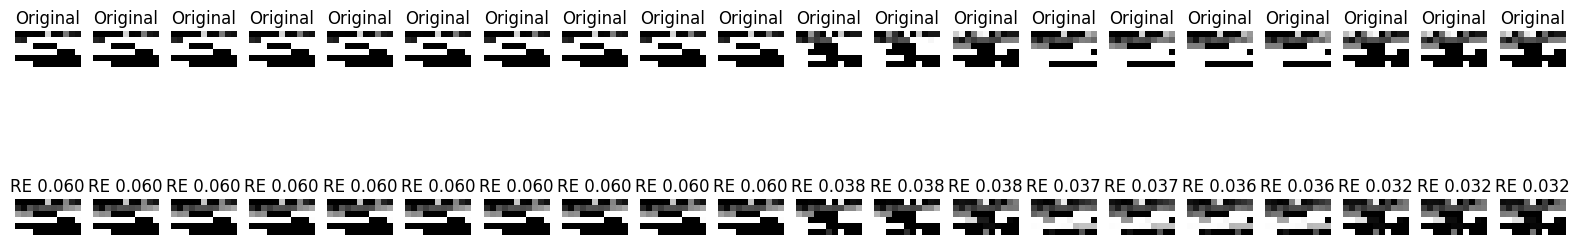

In [57]:
import os
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
LATENT_SPACE_SIZE=6

# 1. Split data to traingin and testing
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'train dataset={x_train.shape}')
print(f'test dataset(normal)={x_test.shape}')

# 2. Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Input placeholder
input_img = Input(shape=(input_dim,))

# Encoder layers
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder layers
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model for later use
encoder = Model(input_img, encoded)

# Decoder model setup
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

# 3. Compile and train the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=50,                      # use some more reasonable number here (>50)
                batch_size=16,
                shuffle=True,
                validation_data=(x_test, x_test))

# 4. Visualize the reconstructed images
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Assuming x_test contains the original test data
# and decoded_imgs are the autoencoder's reconstructed outputs
reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

# Average reconstruction error across all samples
avg_error = np.mean(reconstruction_errors)
max_error = np.max(reconstruction_errors)
min_error = np.min(reconstruction_errors)
print(f"Reconstruction error for each sample {reconstruction_errors}")
print(f"Average={avg_error}, Max={max_error}, Min={min_error} reconstruction errors.")

# Get indices that would sort the array in ascending order
worst20 = np.argsort(reconstruction_errors)[-20:][::-1]

n = 20  # Number of digits to display
i = 0

print("Worst reconstructed:")
plt.figure(figsize=(20, 4))
for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = make_image_from_sample(original) 
    reconstructed = decoded_imgs[j]
    reconstructed = make_image_from_sample(reconstructed) 
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i+=1
plt.show()


# Test with unknown data

Next, we load ISCX data set and use previously trained Autoencoder. The reconstruction error shuld be significantly higher.

In [58]:
# Function to extract features ensuring all columns match what the pipeline expects 
def extract_features_for_pipeline(df, global_top_ccs):
    """
    Extract features ensuring compatibility with the pipeline by using the global top CCS list.
    
    Parameters:
    -----------
    df : DataFrame
        The raw dataframe with TLS records
    global_top_ccs : list
        List of top CCS values used during training
    
    Returns:
    --------
    DataFrame
        Processed dataframe with extracted features
    """
    # For each global CCS value, create a binary feature column
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in global_top_ccs]
    
    # Generate CCS features based on the global list to ensure column alignment
    ccs_features = df['tls.ccs'].apply(lambda x: create_ccs_features(x, global_top_ccs))
    ccs_df = pd.DataFrame(ccs_features.tolist(), columns=ccs_column_names)
    
    # Flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    # TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    # TLS records 
    records_data = pd.DataFrame(pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), columns=tls_columns_names)
    
    # Combine all features
    dataset = pd.concat([flow_data, tls_data, ccs_df, records_data], axis=1).fillna(0)
    return dataset

# This function should be called right after defining the global top CCS values
# in your main training code, before the test code
def initialize_global_top_ccs(top_ccs):
    """
    Initialize the global_top_ccs variable to be used across all dataset testing.
    
    Parameters:
    -----------
    top_ccs : list
        List of top CCS values used during training
    """
    global global_top_ccs
    global_top_ccs = top_ccs
    print(f"Initialized global top CCS list with {len(global_top_ccs)} values")

In [59]:
def test_dataset(json_files, top_ccs, dataset_name="Unnamed Dataset", export_results=False, results_file="tls_test_results.xlsx"):
    """
    Test a TLS dataset and print detailed results in English.
    
    Parameters:
    -----------
    json_files : list or glob pattern
        The JSON files containing TLS records to test
    top_ccs : list
        List of top CCS values used during training
    dataset_name : str
        Name of the dataset being tested (for reporting)
    export_results : bool
        Whether to export results to Excel file
    results_file : str
        Path to Excel file for exporting results
    """
    import pandas as pd
    import time
    from datetime import datetime

    # Start timing
    start_time = time.time()
    
    # Load and process data
    raw_test_df = load_json_files(json_files)
    
    # Find this dataset's own top CCS values (for analysis purposes)
    dataset_top_ccs = find_top_ccs_values(raw_test_df, top_n=TOP_N_CCS)
    print(f"Top 30 cipher suites in {dataset_name}: {dataset_top_ccs}")
    
    # Compare with training dataset's CCS values
    common_ccs = set(dataset_top_ccs) & set(top_ccs)
    unique_ccs = set(dataset_top_ccs) - set(top_ccs)
    print(f"CCS values in common with training data: {len(common_ccs)}")
    print(f"CCS values unique to this dataset: {len(unique_ccs)}")
    if unique_ccs:
        print(f"Unique CCS values: {', '.join(list(unique_ccs)[:10])}")
    
    # Use training top CCS for feature extraction to ensure model compatibility
    input_test_df = extract_features_for_pipeline(raw_test_df, top_ccs)
    
    # Transform data using the pipeline
    test_df = pipeline.transform(input_test_df)
    print(f"Processed dataset shape: {test_df.shape} ({test_df.shape[0]} samples with {test_df.shape[1]} features)")
    
    # Encode and decode using the autoencoder
    encoded_test = encoder.predict(test_df)
    decoded_test = decoder.predict(encoded_test)
    
    # Calculate reconstruction errors
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)
    
    # Calculate statistics
    test_avg_error = np.mean(test_reconstruction_errors)
    test_median_error = np.median(test_reconstruction_errors)
    test_std_error = np.std(test_reconstruction_errors)
    test_min_error = np.min(test_reconstruction_errors)
    test_max_error = np.max(test_reconstruction_errors)
    
    # Get percentiles for better distribution understanding
    percentiles = [25, 50, 75, 90, 95, 99]
    error_percentiles = np.percentile(test_reconstruction_errors, percentiles)
    
    # Get best and worst samples
    best10 = np.argsort(test_reconstruction_errors)[:10]
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    # Print comprehensive results
    print("\nRECONSTRUCTION ERROR ANALYSIS:")
    print(f"Average reconstruction error: {test_avg_error:.6f}")
    print(f"Median reconstruction error:  {test_median_error:.6f}")
    print(f"Std deviation of errors:      {test_std_error:.6f}")
    print(f"Min reconstruction error:     {test_min_error:.6f}")
    print(f"Max reconstruction error:     {test_max_error:.6f}")
    
    print("\nERROR DISTRIBUTION (PERCENTILES):")
    for p, val in zip(percentiles, error_percentiles):
        print(f"{p}th percentile: {val:.6f}")
    
    # Print information about worst samples
    print("\nWORST RECONSTRUCTED SAMPLES:")
    for i, idx in enumerate(worst10):
        print(f"Sample {idx}: Reconstruction Error = {test_reconstruction_errors[idx]:.6f}")
    
    # Print information about best samples
    print("\nBEST RECONSTRUCTED SAMPLES:")
    for i, idx in enumerate(best10):
        print(f"Sample {idx}: Reconstruction Error = {test_reconstruction_errors[idx]:.6f}")
    
    # Visualize results
    n = 10  # Number of samples to display
    plt.figure(figsize=(20, 4))
    for i, j in enumerate(worst10):
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = make_image_from_sample(original)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed)
        
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
    
    plt.suptitle(f"Worst Reconstructed Samples - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    # plt.savefig(f"{dataset_name.replace(' ', '_')}_worst_samples.png")
    plt.show()
    
    # Performance summary
    print("\nPERFORMANCE SUMMARY:")
    print(f"Dataset: {dataset_name}")
    print(f"Number of samples: {raw_test_df.shape[0]}")
    print(f"Number of features: {test_df.shape[1]}")
    print(f"Average reconstruction error: {test_avg_error:.6f}")
    print(f"Processing time: {elapsed_time:.2f} seconds")
    
    # Export results if requested
    if export_results:
        # Prepare results dictionary
        results_dict = {
            'Dataset Name': dataset_name,
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Number of Samples': raw_test_df.shape[0],
            'Number of Features': test_df.shape[1],
            'Average Error': test_avg_error,
            'Median Error': test_median_error,
            'Std Deviation': test_std_error,
            'Min Error': test_min_error,
            'Max Error': test_max_error,
            'Processing Time (s)': elapsed_time
        }
        
        # Add percentiles
        for p, val in zip(percentiles, error_percentiles):
            results_dict[f'Percentile {p}'] = val
        
        # Create DataFrame
        results_df = pd.DataFrame([results_dict])
        
        try:
            # Check if file exists
            if os.path.exists(results_file):
                existing_results = pd.read_excel(results_file)
                updated_results = pd.concat([existing_results, results_df], ignore_index=True)
            else:
                updated_results = results_df
                
            # Save to Excel
            updated_results.to_excel(results_file, index=False)
            print(f"\nResults successfully exported to {results_file}")
            
        except Exception as e:
            pass
            # print(f"\nError exporting results: {e}")
            # Create backup CSV
            # backup_file = f"backup_results_{datetime.now().strftime('%Y%m%d%H%M%S')}.csv"
            # results_df.to_csv(backup_file, index=False)
            # print(f"Created backup CSV: {backup_file}")
    
    return {
        'dataset_name': dataset_name,
        'avg_error': test_avg_error,
        'median_error': test_median_error,
        'std_error': test_std_error,
        'min_error': test_min_error,
        'max_error': test_max_error,
        'raw_shape': raw_test_df.shape,
        'processed_shape': test_df.shape,
        'errors': test_reconstruction_errors,
        'top_ccs': dataset_top_ccs  # Include dataset's own top CCS values in the results
    }

Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0039', '0067']
Top 30 cipher suites: ['002F', '0035', '000A', 'C00A', 'C009', 'C013', 'C014', 'C02B', '0005', '0004', '0033', '0039', '0032', 'C02F', 'C007', 'C011', '0038', '0045', '0088', '0016', '0041', '0084', 'C012', '009E', '009C', '003D', '003C', 'C023', 'C027', '0013']
Top 30 cipher suites in ISCX TLS Dataset: ['002F', '0035', '000A', 'C00A', 'C009', 'C013', 'C014', 'C02B', '0005', '0004', '0033', '0039', '0032', 'C02F', 'C007', 'C011', '0038', '0045', '0088', '0016', '0041', '0084', 'C012', '009E', '009C', '003D', '003C', 'C023', 'C027', '0013']
CCS values in common with training data: 16
CCS values unique to this dataset: 14
Unique CCS values: 0004, 0038, 0032, C007, C011, 0033, 0005, C012, 0084, 0045
Processed dataset shape: (1112,

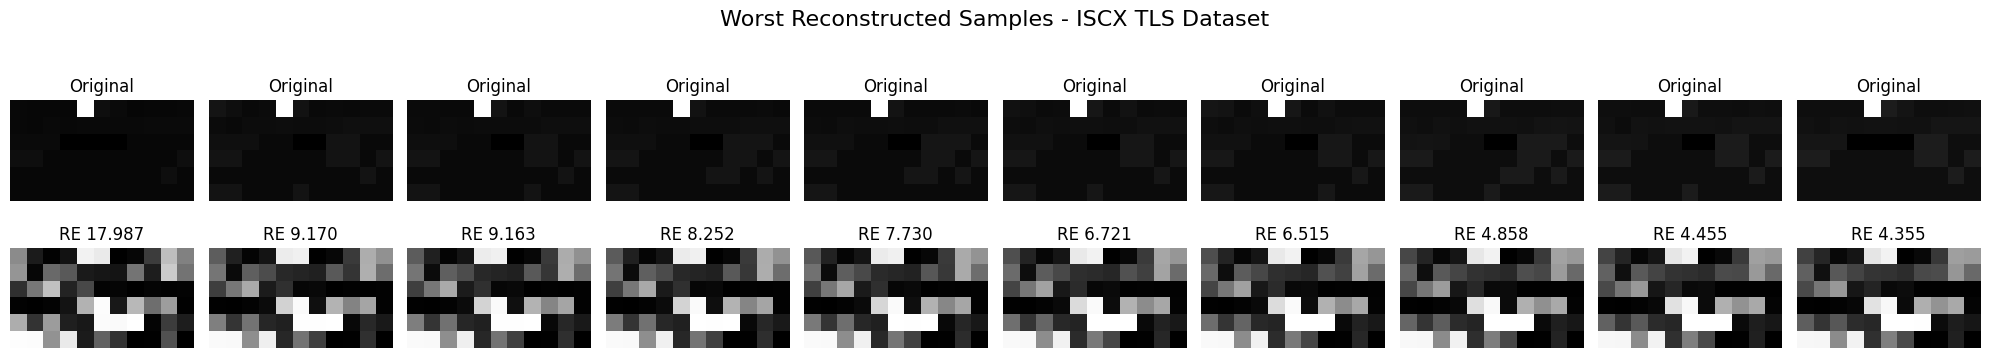


PERFORMANCE SUMMARY:
Dataset: ISCX TLS Dataset
Number of samples: 1112
Number of features: 65
Average reconstruction error: 0.278628
Processing time: 0.21 seconds
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
Top 30 cipher suites in Mobile TLS Dataset: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
CCS values in common with training data: 27
CCS values unique to this dataset: 3
Unique CCS values: CCAA, C012, C008
Processed dataset shape: (5616, 65) (5616 samples with 65 features)
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step

RECONSTRUCTION E

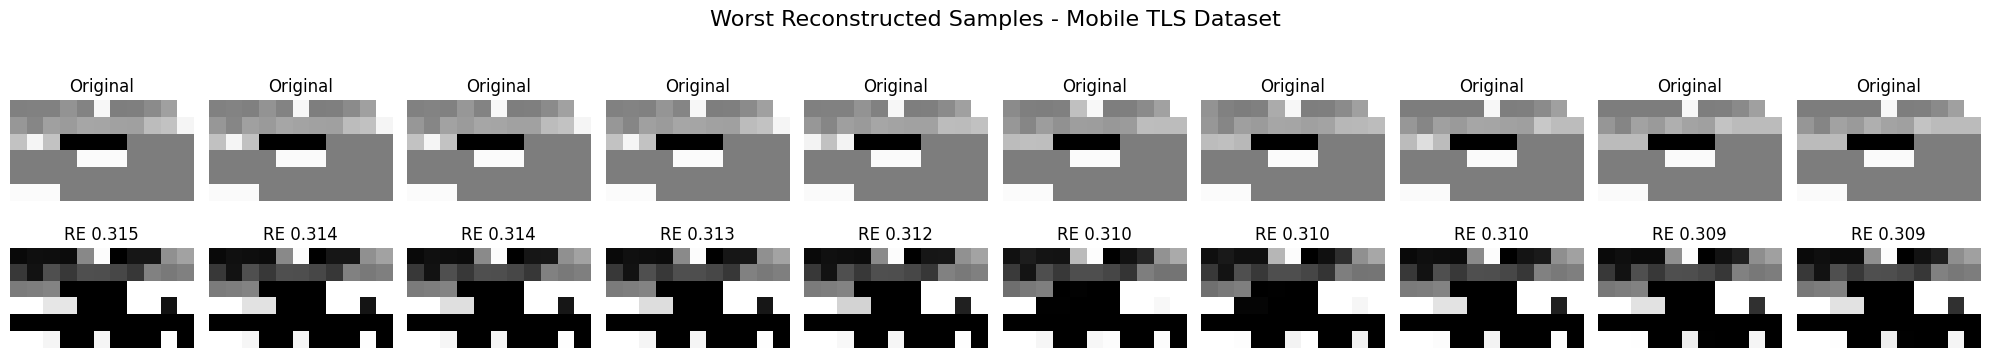


PERFORMANCE SUMMARY:
Dataset: Mobile TLS Dataset
Number of samples: 5616
Number of features: 65
Average reconstruction error: 0.026093
Processing time: 0.62 seconds
Top 30 cipher suites: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
Top 30 cipher suites in windows TLS Dataset: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
CCS values in common with training data: 30
CCS values unique to this dataset: 0
Processed dataset shape: (15047, 65) (15047 samples with 65 features)
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 307us/step
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step

RECONSTRUCTION ERROR ANALYSIS:
Average reconstr

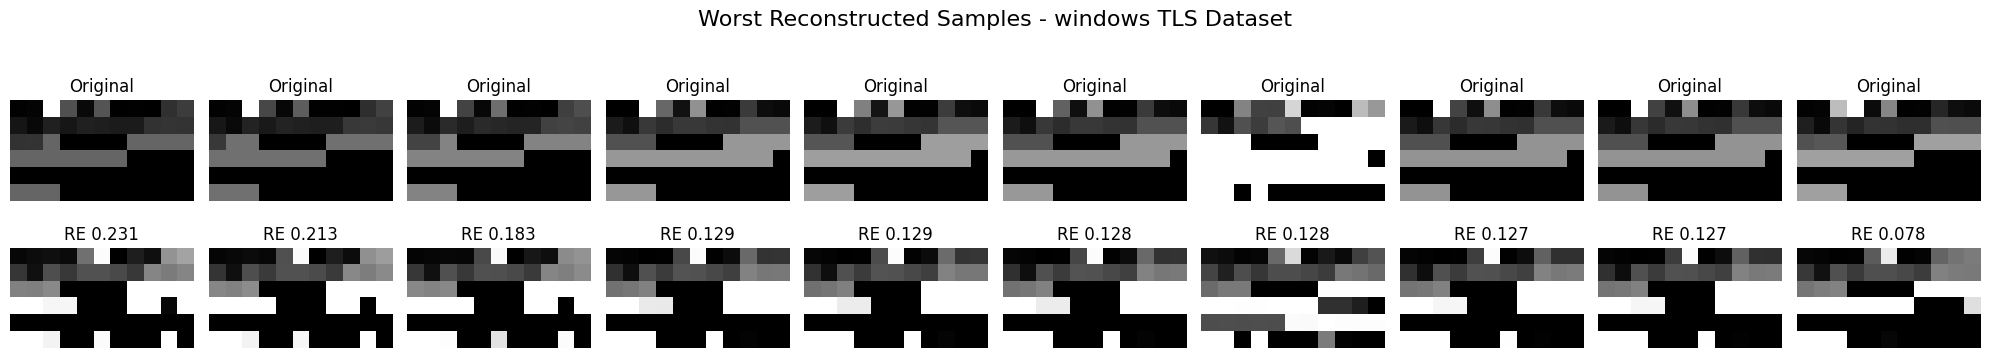


PERFORMANCE SUMMARY:
Dataset: windows TLS Dataset
Number of samples: 15047
Number of features: 65
Average reconstruction error: 0.003871
Processing time: 1.71 seconds
Top 30 cipher suites: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
Top 30 cipher suites in cic-aa.normal TLS Dataset: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0004, C011, C007, 0033, 0005, 0003, 0006, 0009, 0008, CC14
Processed dataset shape: (31179, 65) (31179 samples with 65 features)
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step
975/

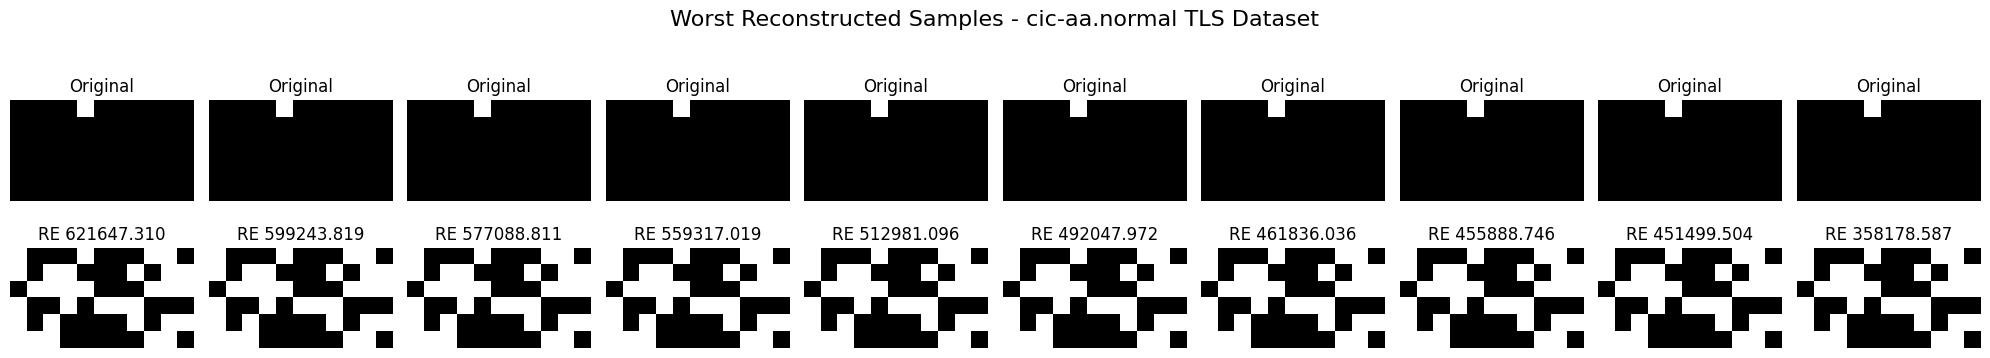


PERFORMANCE SUMMARY:
Dataset: cic-aa.normal TLS Dataset
Number of samples: 31179
Number of features: 65
Average reconstruction error: 379.006942
Processing time: 3.67 seconds
Top 30 cipher suites: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
Top 30 cipher suites in cic-aa.malware TLS Dataset: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0004, C011, C007, 0033, 0005, 0003, 0006, 0009, 0008, CC14
Processed dataset shape: (462, 65) (462 samples with 65 features)
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
15

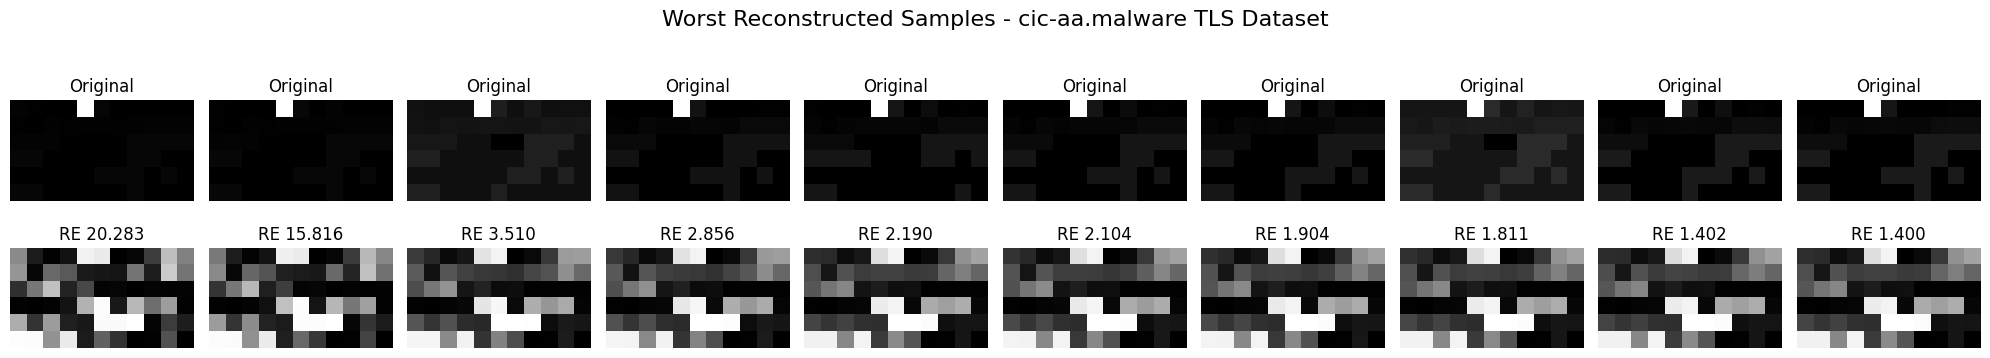


PERFORMANCE SUMMARY:
Dataset: cic-aa.malware TLS Dataset
Number of samples: 462
Number of features: 65
Average reconstruction error: 0.360218
Processing time: 0.17 seconds
Top 30 cipher suites: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
Top 30 cipher suites in cic-aa.adware TLS Dataset: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: C022, 0004, C011, C007, 0033, 0005, C021, CC15, CC14, CC13
Processed dataset shape: (7122, 65) (7122 samples with 65 features)
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step
2

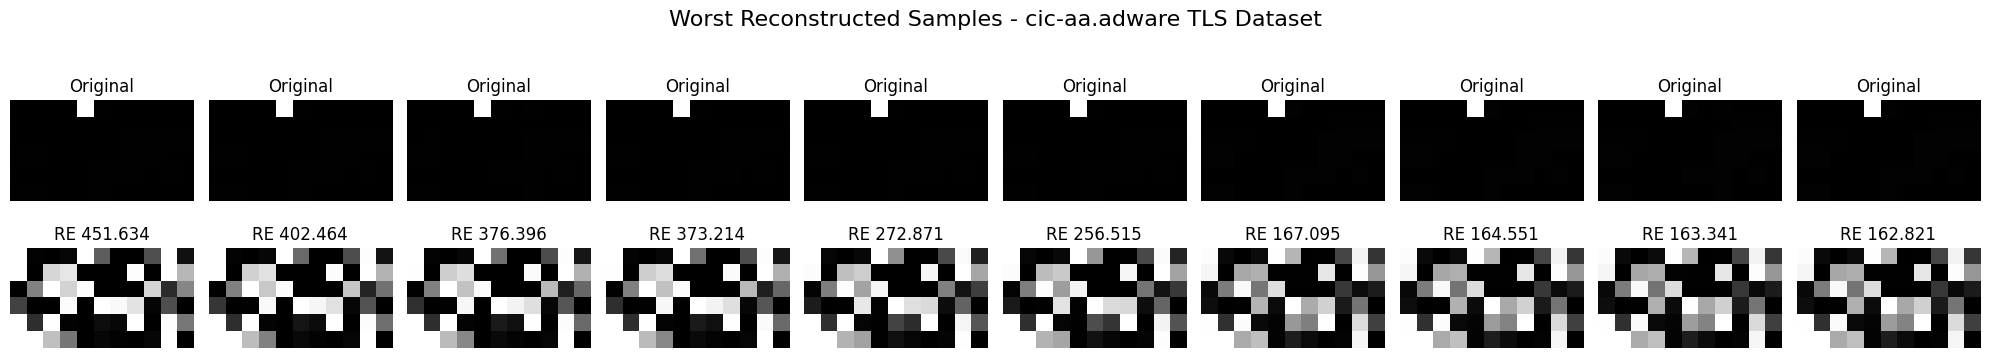


PERFORMANCE SUMMARY:
Dataset: cic-aa.adware TLS Dataset
Number of samples: 7122
Number of features: 65
Average reconstruction error: 0.864760
Processing time: 1.09 seconds

COMPARISON OF DATASETS
                   Dataset  Samples  Features  Avg Error     Max Error  Min Error
          ISCX TLS Dataset     1112        65   0.278628     17.987428   0.028705
        Mobile TLS Dataset     5616        65   0.026093      0.314903   0.000215
       windows TLS Dataset    15047        65   0.003871      0.230722   0.000133
 cic-aa.normal TLS Dataset    31179        65 379.006942 621647.309584   0.009504
cic-aa.malware TLS Dataset      462        65   0.360218     20.283264   0.014326
 cic-aa.adware TLS Dataset     7122        65   0.864760    451.633921   0.050094

CCS USAGE COMPARISON BETWEEN DATASETS
Total unique CCS values across all datasets: 56
CCS values common to all datasets: 11
Common CCS: C02B, C013, C02F, 002F, 000A, 009E, 0035, C009, C00A, C014, 009C

CCS values unique to iscx:

In [60]:
results = {}

raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
input_df, top_ccs = extract_features(raw_df)

# Test ISCX dataset
results['iscx'] = test_dataset(
    json_files=glob.glob("../datasets/iscx.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="ISCX TLS Dataset",
    export_results=True
)

# Test Mobile dataset
results['mobile'] = test_dataset(
    glob.glob("../datasets/mobile.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Mobile TLS Dataset",
    export_results=True
)

results['windows'] = test_dataset(
    glob.glob("../datasets/windows.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="windows TLS Dataset",
    export_results=True
)

results['cic-aa.normal'] = test_dataset(
    glob.glob("../datasets/cic-aa.normal.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="cic-aa.normal TLS Dataset",
    export_results=True
)

results['cic-aa.malware'] = test_dataset(
    glob.glob("../datasets/cic-aa.malware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="cic-aa.malware TLS Dataset",
    export_results=True
)

results['cic-aa.adware'] = test_dataset(
    glob.glob("../datasets/cic-aa.adware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="cic-aa.adware TLS Dataset",
    export_results=True
)

# Compare datasets
print("\n" + "="*80)
print("COMPARISON OF DATASETS")
print("="*80)

comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Dataset': result['dataset_name'],
        'Samples': result['raw_shape'][0],
        'Features': result['processed_shape'][1],
        'Avg Error': result['avg_error'],
        'Max Error': result['max_error'],
        'Min Error': result['min_error']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Optional: Analysis of CCS differences between datasets
print("\n" + "="*80)
print("CCS USAGE COMPARISON BETWEEN DATASETS")
print("="*80)

# Skip normal_test as it doesn't have top_ccs
dataset_ccs = {name: result.get('top_ccs', []) for name, result in results.items() if 'top_ccs' in result}

# Find common and unique CCS across datasets
all_ccs = set()
for ccs_list in dataset_ccs.values():
    all_ccs.update(ccs_list)

print(f"Total unique CCS values across all datasets: {len(all_ccs)}")

# Count how many datasets each CCS appears in
ccs_dataset_count = {ccs: sum(1 for ccs_list in dataset_ccs.values() if ccs in ccs_list) for ccs in all_ccs}

# Find common CCS (in all datasets)
common_ccs = [ccs for ccs, count in ccs_dataset_count.items() if count == len(dataset_ccs)]
print(f"CCS values common to all datasets: {len(common_ccs)}")
if common_ccs:
    print(f"Common CCS: {', '.join(common_ccs)}")

# Find unique CCS (in only one dataset)
for name, ccs_list in dataset_ccs.items():
    unique_to_dataset = [ccs for ccs in ccs_list if ccs_dataset_count[ccs] == 1]
    if unique_to_dataset:
        print(f"\nCCS values unique to {name}: {len(unique_to_dataset)}")
        print(f"Unique CCS: {', '.join(unique_to_dataset[:10])}{'...' if len(unique_to_dataset) > 10 else ''}")